In [1]:
import time
notebook_start = time.perf_counter()

import  os
import  json
import  pandas as pd
import  numpy as np
import  joblib
import  matplotlib.pyplot as plt
import  thermoift.PLOT_SETTINGS as ps
from    thermoift import MLPostprocessing, plot_correlation_heatmap, print_model_metrics
from    thermoift.rng_utils import get_rng
from    sklearn.model_selection import train_test_split, cross_validate

In [2]:
PLOT_FOLDER     = "TabPFN_P_dew_OUTPUTS"
SLURM_RUN_FULL  = False
TEST_ROWS       = None
SEED            = 855015

In [3]:
# Parameters
PLOT_FOLDER = "SLURM_Pdew"
SLURM_RUN_FULL = True
TEST_ROWS = None
SEED = 6702315


In [4]:
try:
    import tabpfn
    from tabpfn import TabPFNRegressor
    from tabpfn.constants import ModelVersion

    if SLURM_RUN_FULL:
        os.environ["TABPFN_ALLOW_CPU_LARGE_DATASET"] = "1"

    print(f"TabPFN version: {tabpfn.__version__}")
    print("Selected model version:", ModelVersion.V2)

except ImportError as exc:
    raise ImportError("tabpfn is not installed in this Python environment.") from exc

# Respect SLURM CPU allocation — use all allocated CPUs
n_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", os.cpu_count() or 4))
os.environ["OMP_NUM_THREADS"]      = str(n_cpus)
os.environ["MKL_NUM_THREADS"]      = str(n_cpus)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cpus)
os.environ["NUMEXPR_NUM_THREADS"]  = str(n_cpus)
try:
    import torch
    torch.set_num_threads(n_cpus)
except ImportError:
    pass
print(f"Thread limit set to {n_cpus} (SLURM_CPUS_PER_TASK)")

TabPFN version: 7.1.1
Selected model version: ModelVersion.V2
Thread limit set to 64 (SLURM_CPUS_PER_TASK)


In [5]:
df = pd.read_csv("../../interfacial_results_dataset_A4.csv")
print(f"Number of rows: {len(df)}")

if not SLURM_RUN_FULL:
    df = df.iloc[:TEST_ROWS].copy()
    print(f"Test mode: using first {TEST_ROWS} rows only")
else:
    print("Full mode: using all rows")

print(f"Total samples: {len(df)}")
print(f"\nP_dew statistics:")
print(df["P_dew"].describe())

Number of rows: 19361
Full mode: using all rows
Total samples: 19361

P_dew statistics:
count    19361.000000
mean        23.025120
std         18.245683
min          2.623504
25%          6.876419
50%         16.994768
75%         35.466456
max         78.580621
Name: P_dew, dtype: float64


In [6]:
target     = "P_dew"
rng        = get_rng(seed=SEED)

z_columns  = [col for col in df.columns if col.startswith("z_")]
Z_non_zero = [col for col in z_columns if (df[col] != 0).any()]
features   = ["temperature", "pressure"] + Z_non_zero

print(f"Selected features: {features}")

X = df[features]
y = df[target]

# 70/15/15 split: first 70/30, then split 30 into 15/15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"\nTraining samples:   {X_train.shape[0]}")
print(f"Testing samples:    {X_test.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Selected features: ['temperature', 'pressure', 'z_carbon dioxide', 'z_hydrogen', 'z_nitrogen', 'z_argon', 'z_methane', 'z_oxygen', 'z_carbon monoxide', 'z_hydrogen sulfide']

Training samples:   13552
Testing samples:    2904
Validation samples: 2905


Feature correlations with P_dew:
temperature           0.957710
pressure              0.805453
z_hydrogen            0.053917
z_argon               0.009879
z_hydrogen sulfide    0.005369
z_nitrogen           -0.004146
z_carbon monoxide    -0.004547
z_methane            -0.005615
z_oxygen             -0.007839
z_carbon dioxide     -0.026539
Name: P_dew, dtype: float64


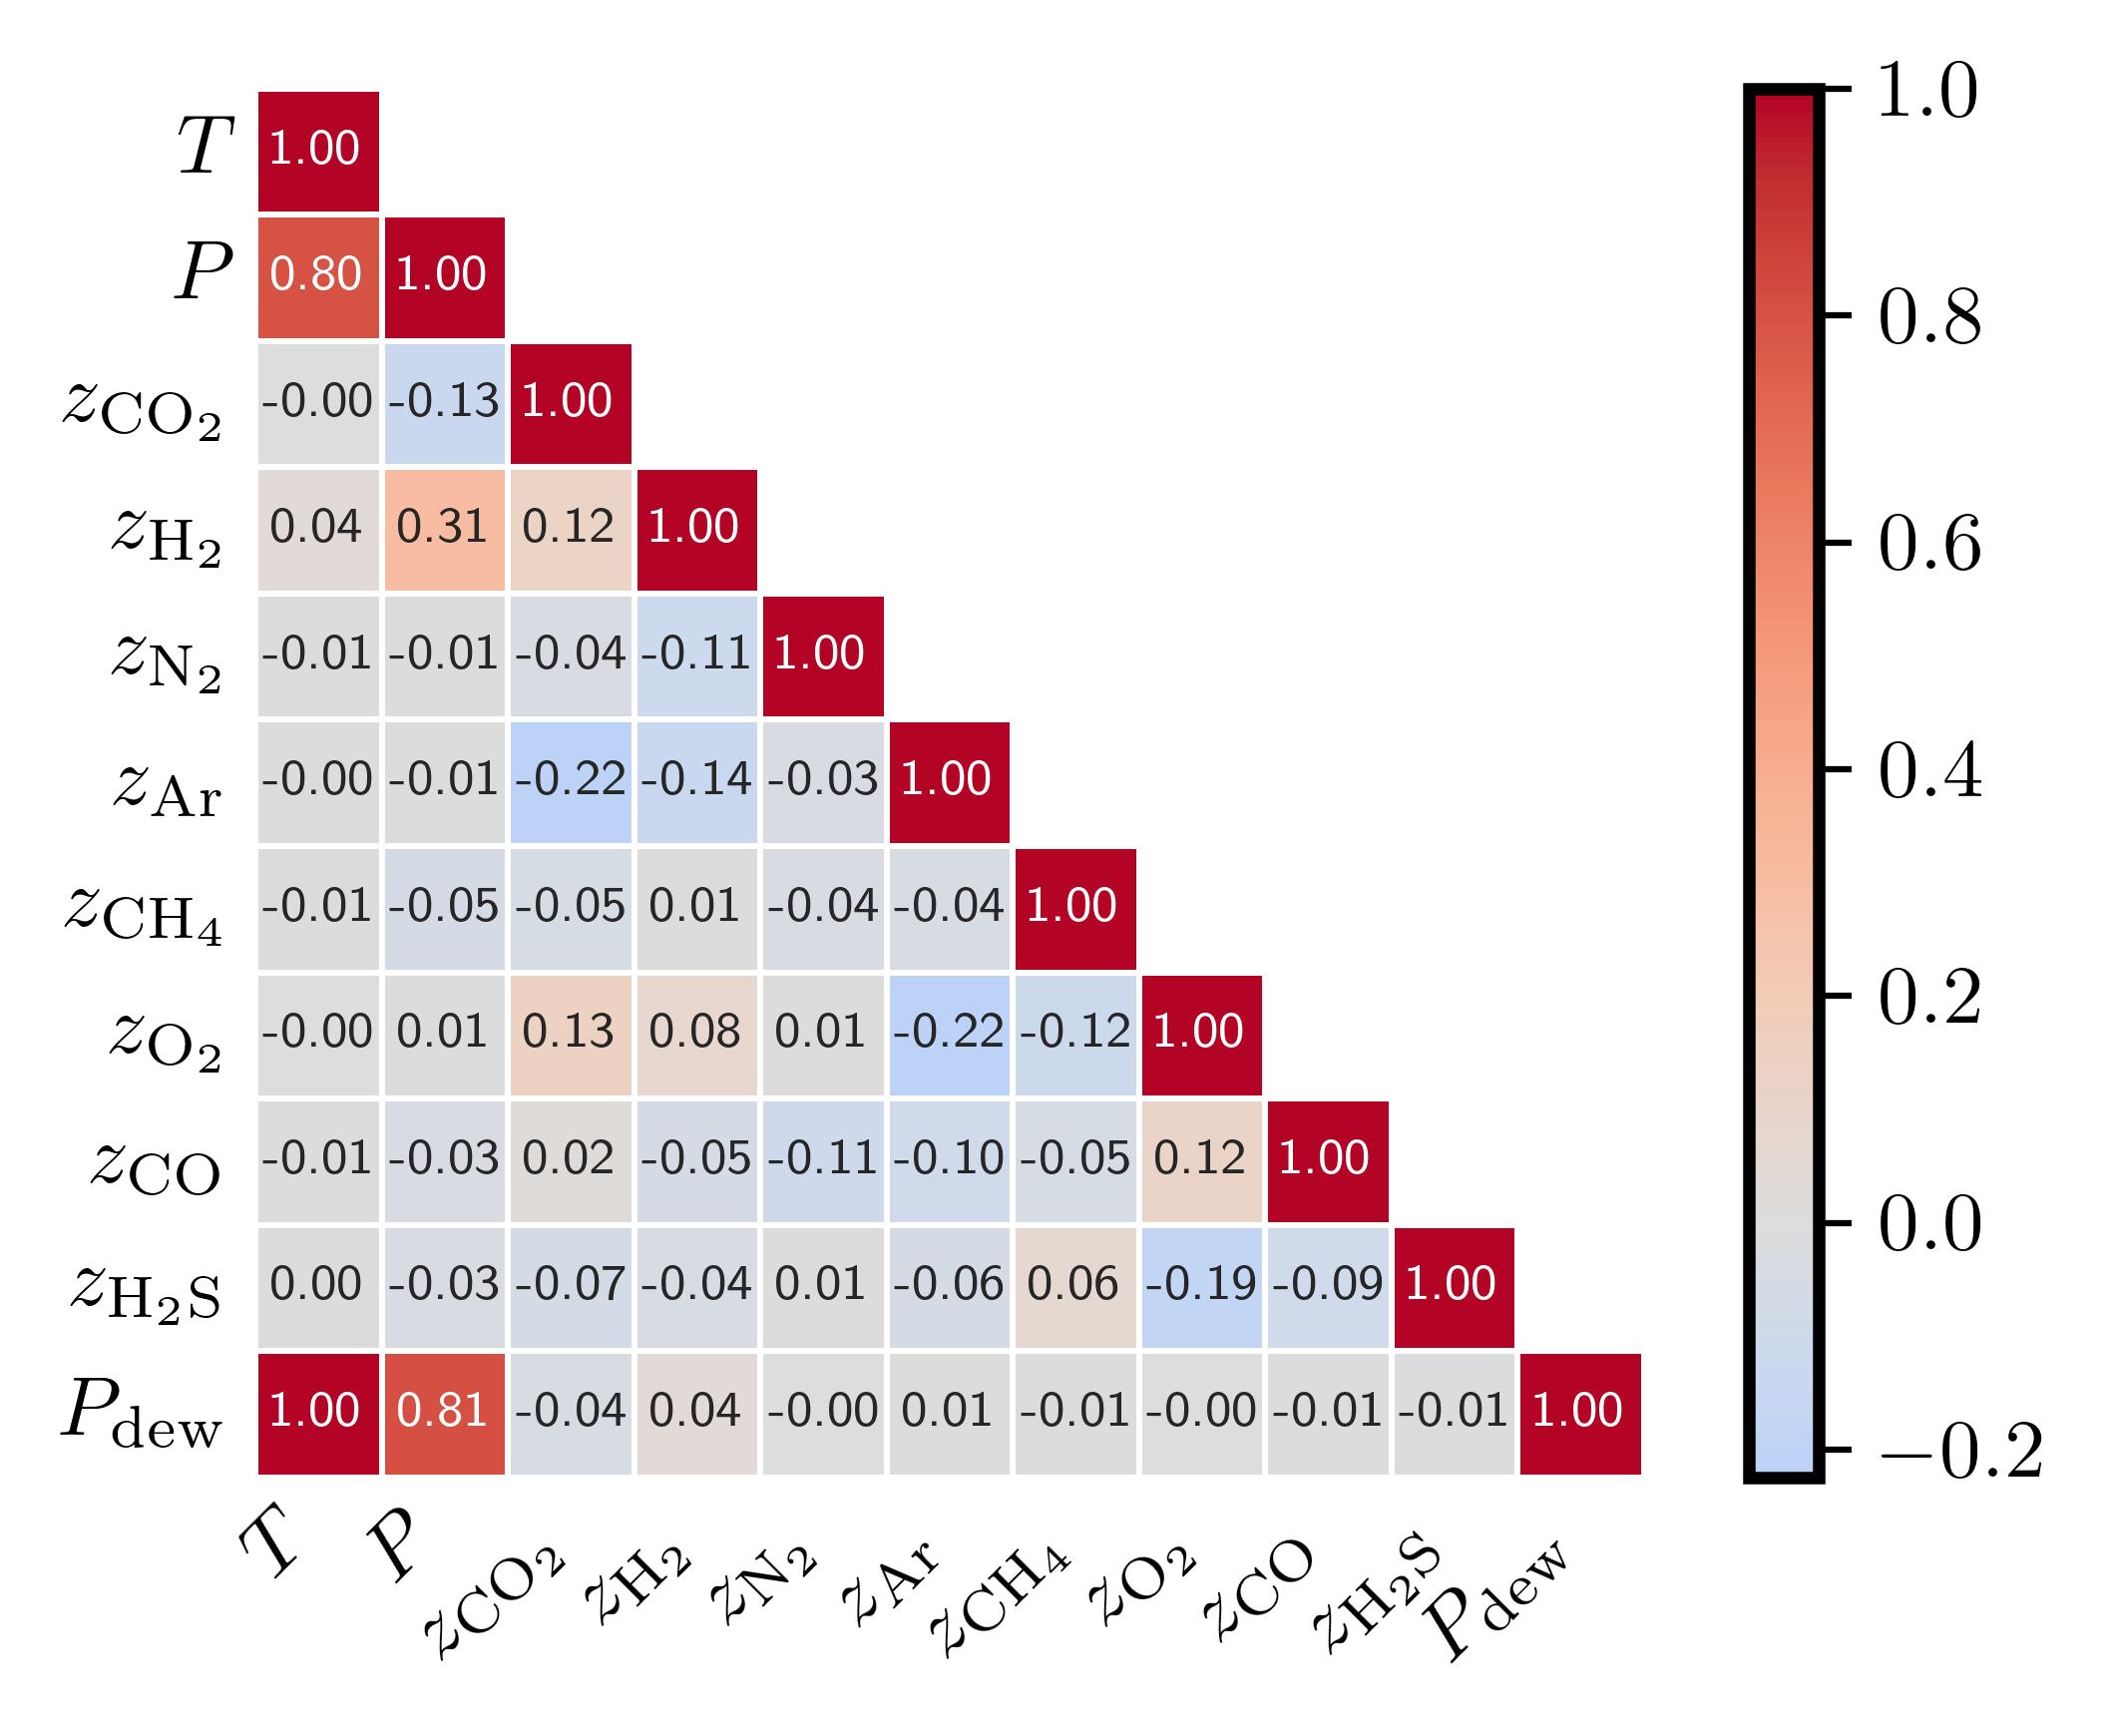

(<Figure size 2400x1800 with 2 Axes>, <Axes: >)

In [7]:
plot_correlation_heatmap(df, features, target, save_path="TabPFN_P_dew_correlation", folder=PLOT_FOLDER)

In [8]:
# Train TabPFN model
tabpfn_model = TabPFNRegressor(random_state=SEED, ignore_pretraining_limits=True, fit_mode="fit_preprocessors")
tabpfn_model.fit(X_train, y_train)

# Predictions
y_train_pred = tabpfn_model.predict(X_train)
y_test_pred  = tabpfn_model.predict(X_test)
y_val_pred   = tabpfn_model.predict(X_val)

# Metrics
metrics = print_model_metrics(y_train, y_train_pred, y_test, y_test_pred, target, y_val=y_val, y_val_pred=y_val_pred)

Model Performance for P_dew

Training Set:
  R²:   0.999897
  RMSE: 0.185101 bar
  MAE:  0.109188 bar

Test Set:
  R²:   0.999892
  RMSE: 0.190183 bar
  MAE:  0.110153 bar

Validation Set:
  R²:   0.999887
  RMSE: 0.191187 bar
  MAE:  0.109065 bar


In [9]:
# Save predictions for post-hoc outlier analysis (no retraining needed)
results_df = pd.DataFrame({
    "idx": np.concatenate([y_train.index, y_test.index, y_val.index]),
    "actual": np.concatenate([y_train.values, y_test.values, y_val.values]),
    "predicted": np.concatenate([y_train_pred, y_test_pred, y_val_pred]),
    "split": ["train"]*len(y_train) + ["test"]*len(y_test) + ["val"]*len(y_val),
})
os.makedirs(PLOT_FOLDER, exist_ok=True)
results_df.to_csv(os.path.join(PLOT_FOLDER, f"TabPFN_{target}_predictions.csv"), index=False)
print(f"Predictions saved: {len(results_df)} rows")

# Save fitted model for future use without retraining
model_path = os.path.join(PLOT_FOLDER, f"TabPFN_{target}_model.joblib")
joblib.dump(tabpfn_model, model_path)
print(f"Model saved to: {model_path}")

Predictions saved: 19361 rows


Model saved to: SLURM_Pdew/TabPFN_P_dew_model.joblib


In [10]:
# 5-fold cross-validation
cv_results = cross_validate(
    tabpfn_model, X, y, cv=5,
    scoring={
        "r2":   "r2",
        "rmse": "neg_root_mean_squared_error",
        "mae":  "neg_mean_absolute_error",
    },
    n_jobs=1,
)

cv_r2_scores   = cv_results["test_r2"]
cv_rmse_scores = -cv_results["test_rmse"]
cv_mae_scores  = -cv_results["test_mae"]

print(f"Cross-Validation R² Scores:   {cv_r2_scores}")
print(f"Mean CV R²:   {cv_r2_scores.mean():.6f} (+/- {cv_r2_scores.std() * 2:.6f})")
print(f"\nCross-Validation RMSE Scores: {cv_rmse_scores}")
print(f"Mean CV RMSE: {cv_rmse_scores.mean():.6f} (+/- {cv_rmse_scores.std() * 2:.6f})")
print(f"\nCross-Validation MAE Scores:  {cv_mae_scores}")
print(f"Mean CV MAE:  {cv_mae_scores.mean():.6f} (+/- {cv_mae_scores.std() * 2:.6f})")

Cross-Validation R² Scores:   [0.99981839 0.99971648 0.99944139 0.99956619 0.99961366]
Mean CV R²:   0.999631 (+/- 0.000257)

Cross-Validation RMSE Scores: [0.24050771 0.30674269 0.43269859 0.38446975 0.36128563]
Mean CV RMSE: 0.345141 (+/- 0.132352)

Cross-Validation MAE Scores:  [0.16004207 0.18178944 0.19287667 0.21013602 0.21775815]
Mean CV MAE:  0.192520 (+/- 0.041157)


In [11]:
# Initialize MLPostprocessing
post = MLPostprocessing(
    y_true=y_test,
    y_pred=y_test_pred,
    target="P_dew",
    feature_names=features,
    datasets={
        "train": (y_train, y_train_pred),
        "test":  (y_test,  y_test_pred),
        "val":   (y_val,   y_val_pred),
    },
)

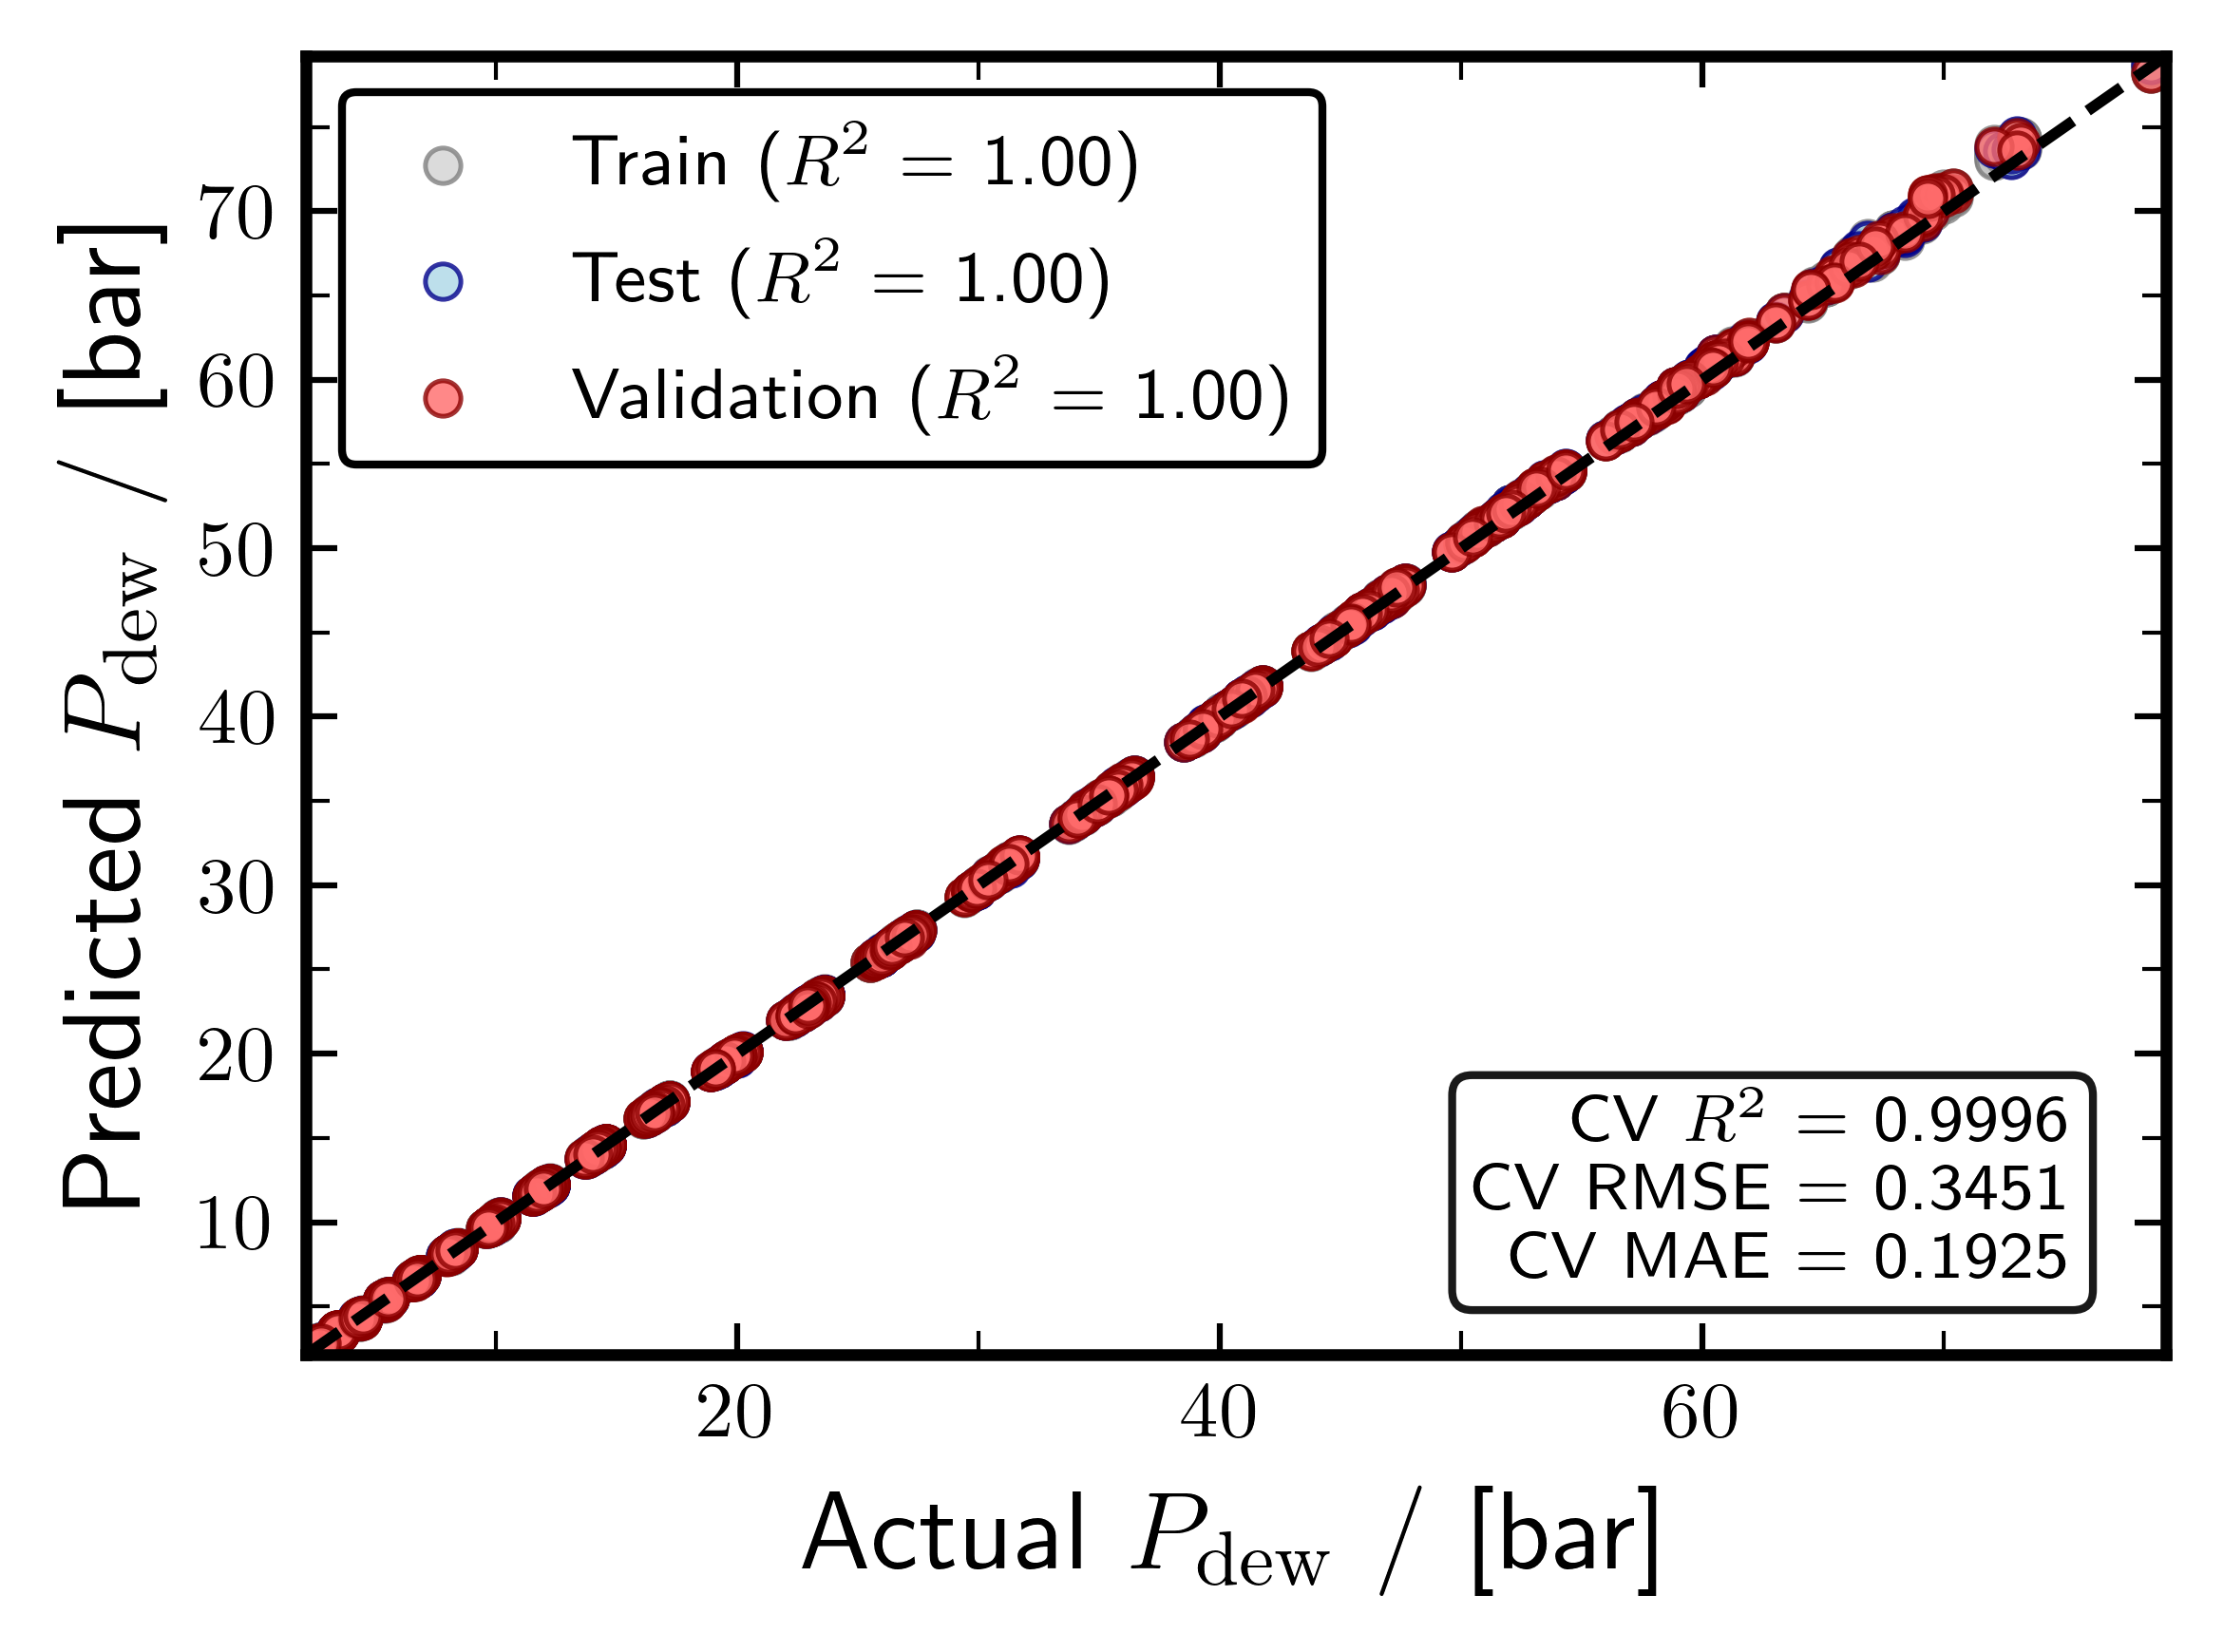

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Actual $P_{\\mathrm{dew}}$ / [bar]', ylabel='Predicted $P_{\\mathrm{dew}}$ / [bar]'>)

In [12]:
# Parity plot
post.plot_parity(model_name="TabPFN", save_path="TabPFN_P_dew_parity_plot", folder=PLOT_FOLDER,
                 cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean(), cv_mae=cv_mae_scores.mean())

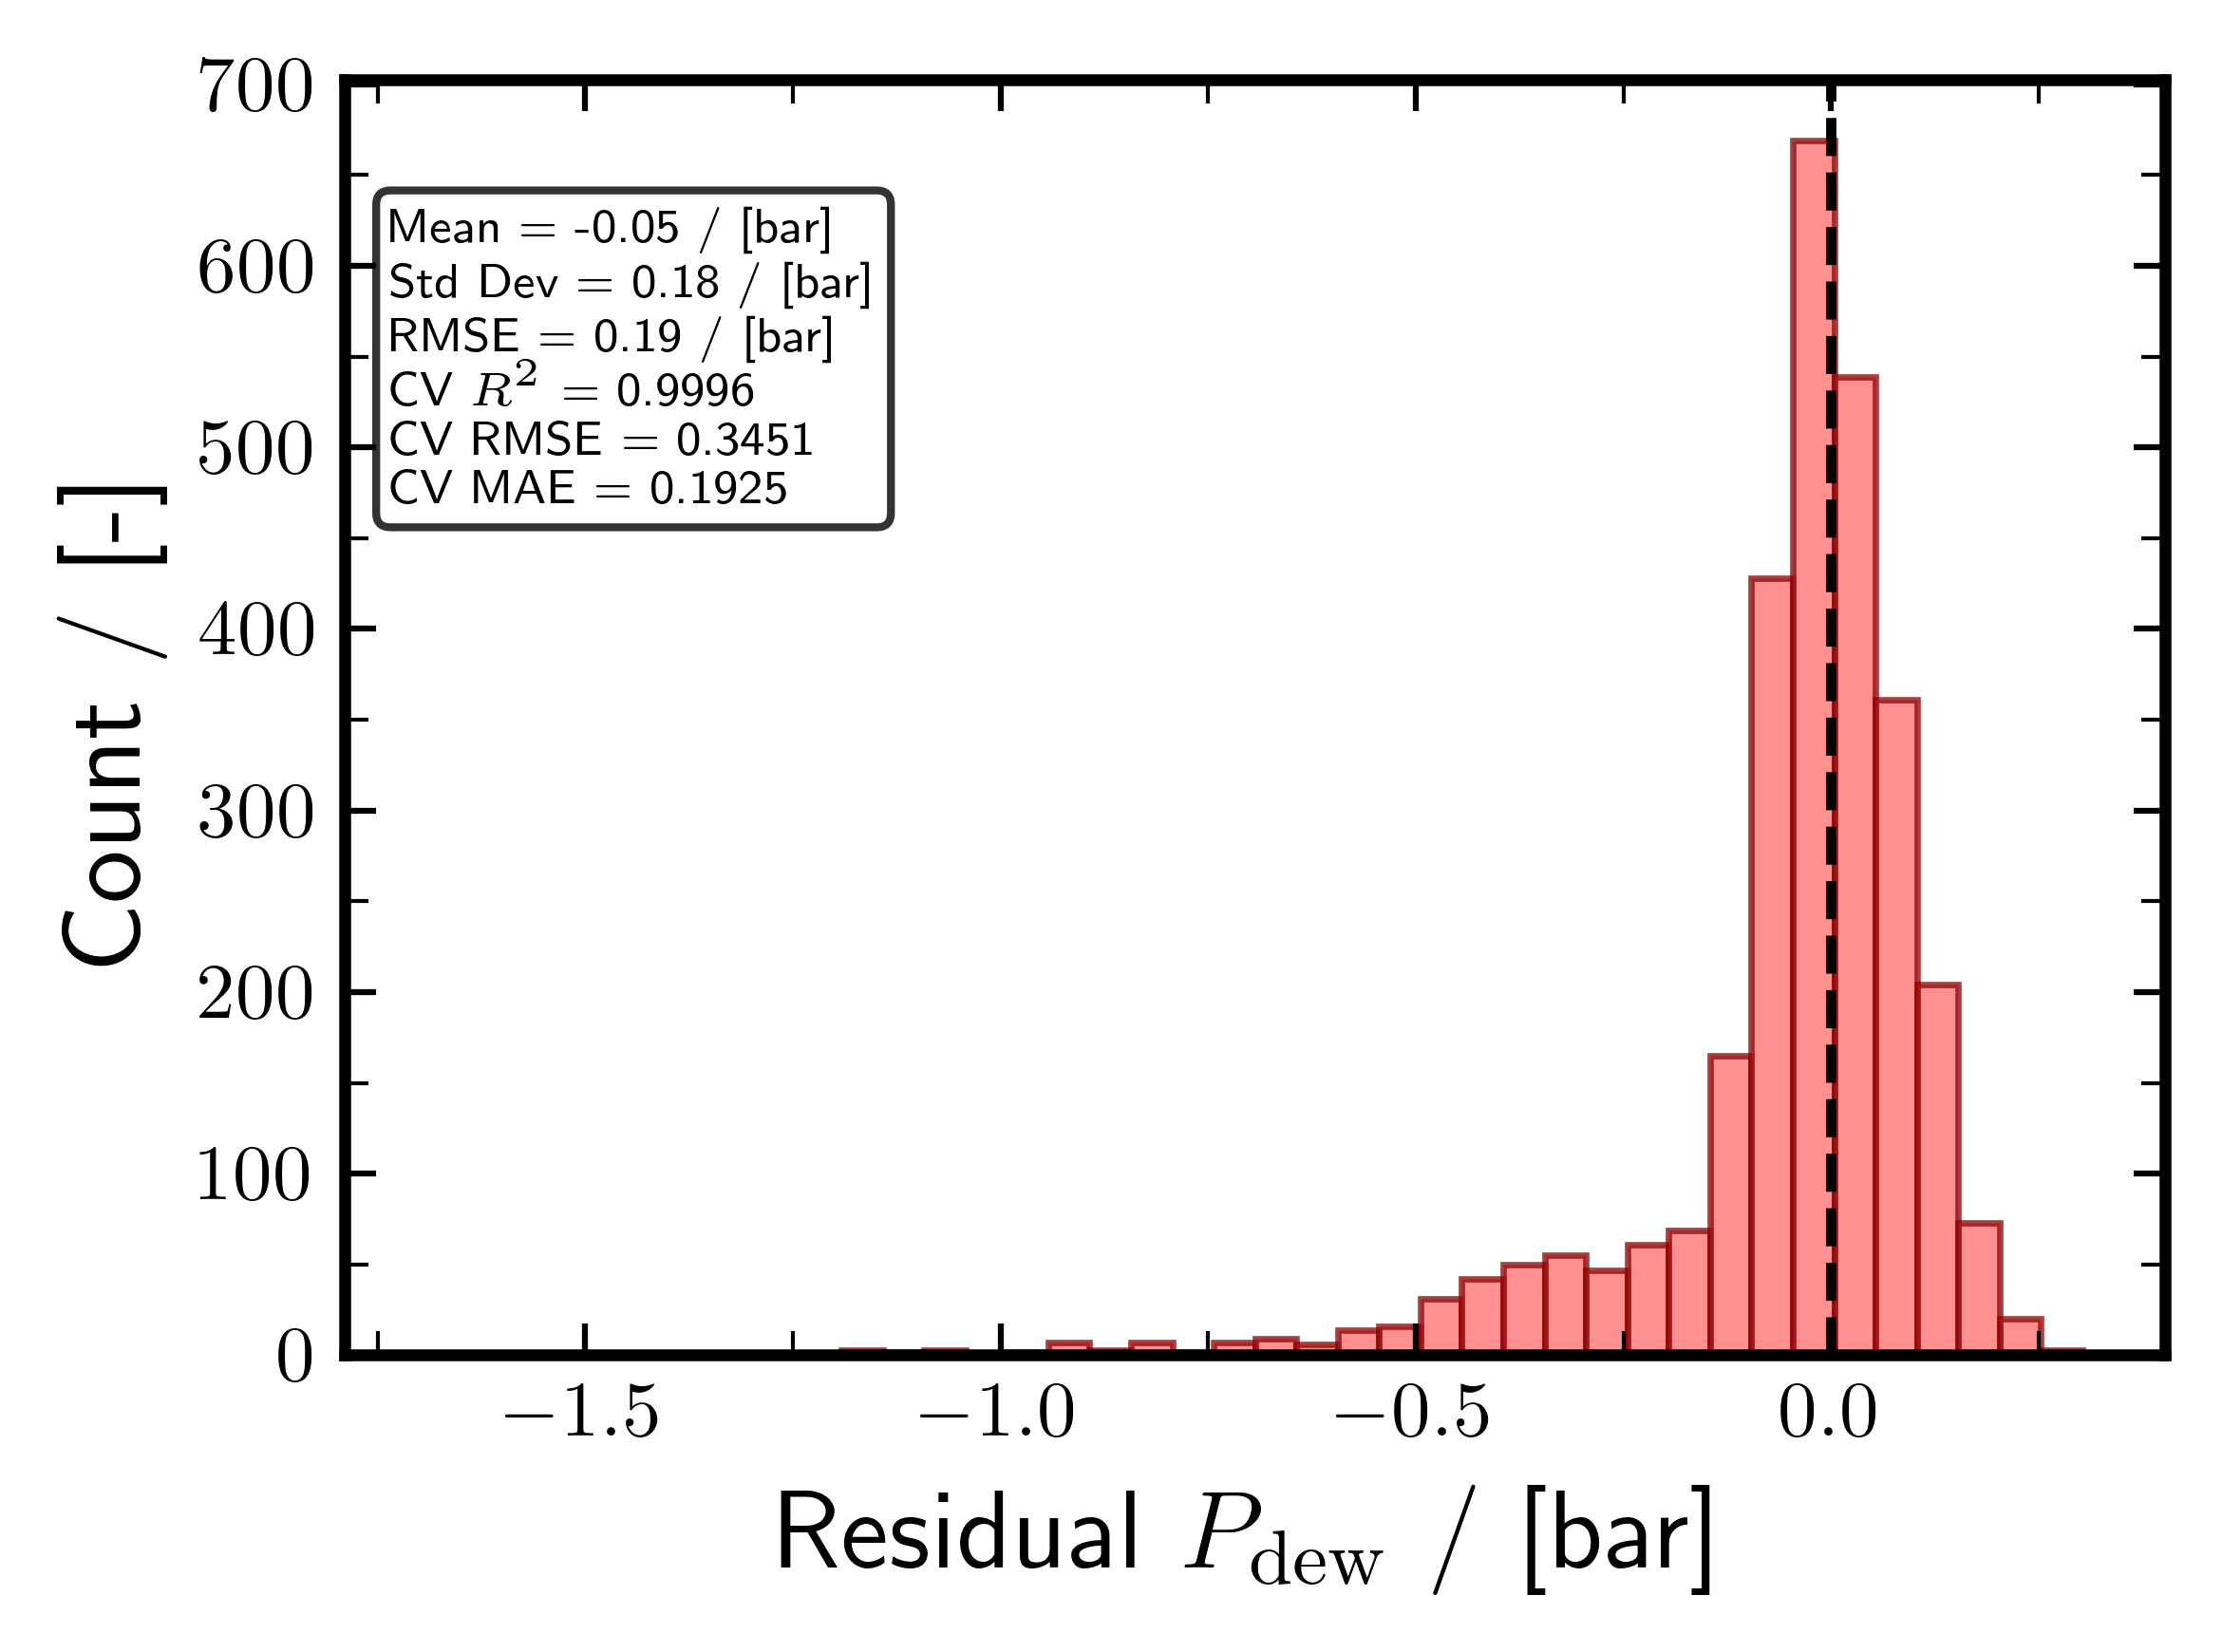

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Residual $P_{\\mathrm{dew}}$ / [bar]', ylabel='Count / [-]'>)

In [13]:
# Residual distribution
post.plot_residual_distribution(save_path="TabPFN_P_dew_residual_distribution", folder=PLOT_FOLDER,
                                cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean(), cv_mae=cv_mae_scores.mean())

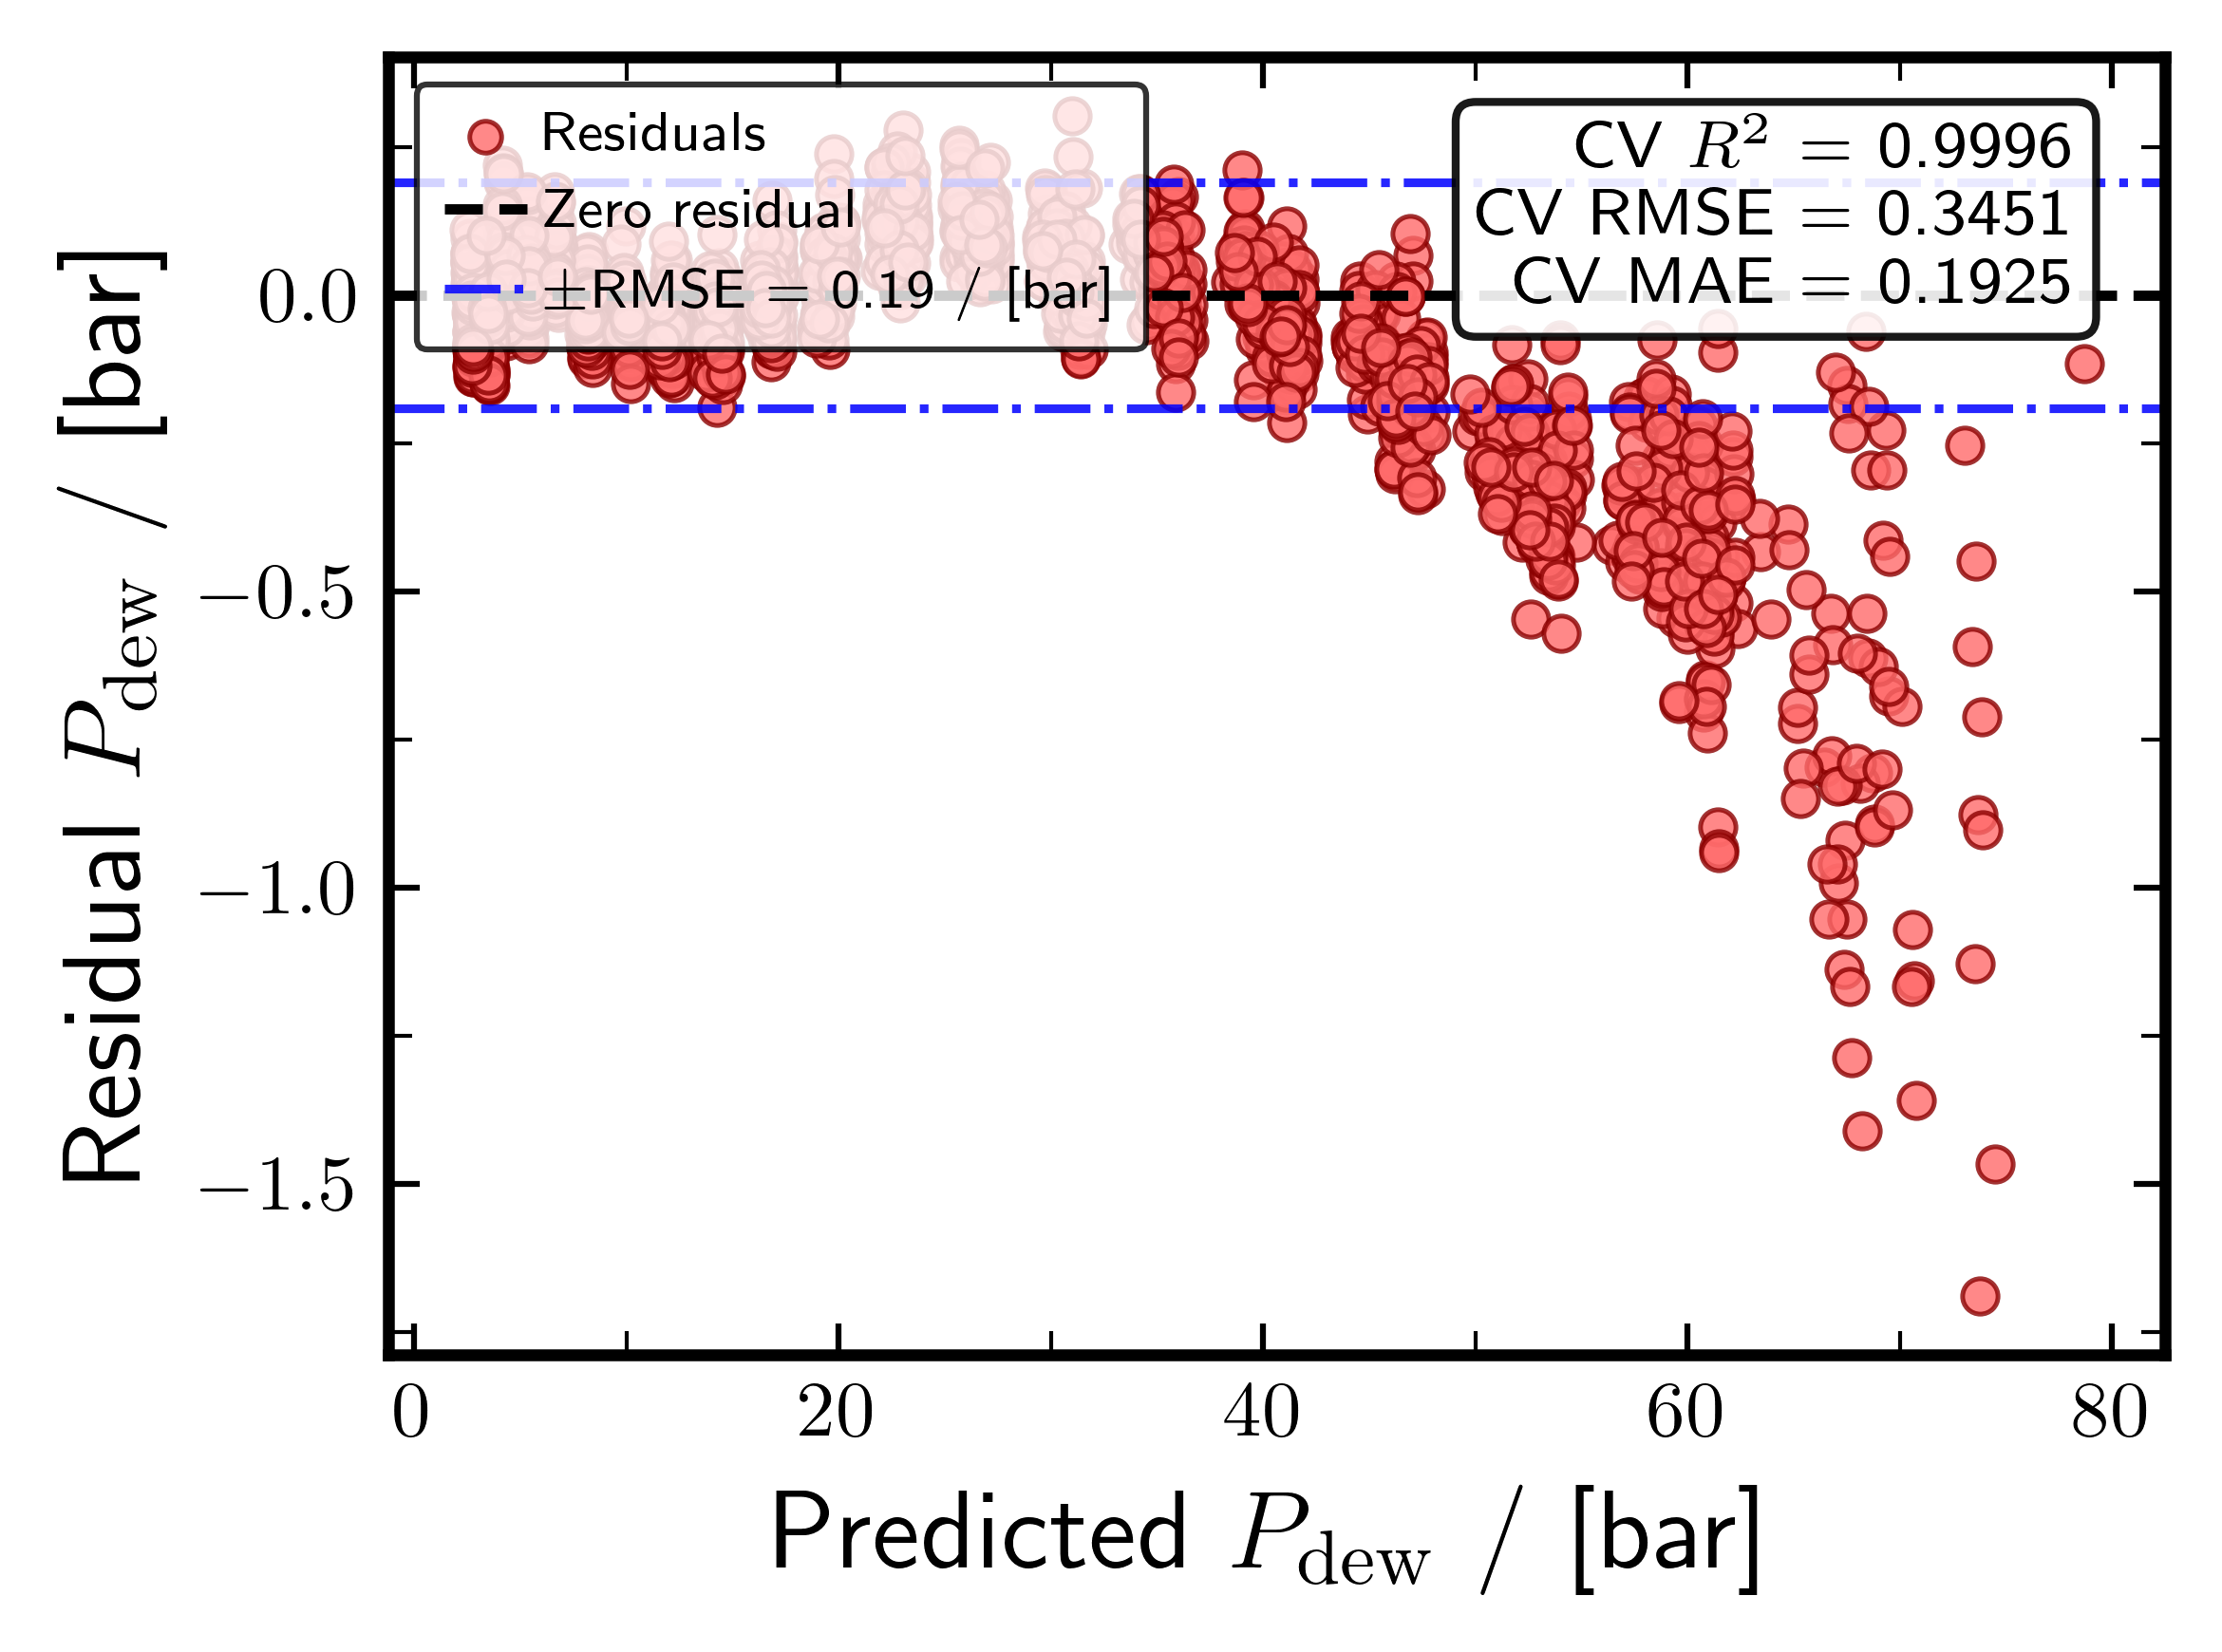

(<Figure size 2400x1800 with 1 Axes>,
 <Axes: xlabel='Predicted $P_{\\mathrm{dew}}$ / [bar]', ylabel='Residual $P_{\\mathrm{dew}}$ / [bar]'>)

In [14]:
# Residuals vs Predicted
post.plot_residual_vs_predicted(save_path="TabPFN_P_dew_residual_vs_predicted", folder=PLOT_FOLDER,
                                cv_r2=cv_r2_scores.mean(), cv_rmse=cv_rmse_scores.mean(), cv_mae=cv_mae_scores.mean())

In [15]:
post.print_summary()

# Collect all metrics
metrics["cv_r2_scores"]    = cv_r2_scores.tolist()
metrics["cv_r2_mean"]      = float(cv_r2_scores.mean())
metrics["cv_r2_std"]       = float(cv_r2_scores.std())
metrics["cv_rmse_scores"]  = cv_rmse_scores.tolist()
metrics["cv_rmse_mean"]    = float(cv_rmse_scores.mean())
metrics["cv_rmse_std"]     = float(cv_rmse_scores.std())
metrics["cv_mae_scores"]   = cv_mae_scores.tolist()
metrics["cv_mae_mean"]     = float(cv_mae_scores.mean())
metrics["cv_mae_std"]      = float(cv_mae_scores.std())
metrics["model"]           = "TabPFN"
metrics["features"]        = features
metrics["target"]          = target
metrics["seed"]            = SEED

# Save metrics to JSON
os.makedirs(PLOT_FOLDER, exist_ok=True)
metrics_path = os.path.join(PLOT_FOLDER, f"TabPFN_{target}_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2, default=str)

print(f"\nMetrics saved to: {metrics_path}")

MODEL PERFORMANCE SUMMARY - P_DEW
Samples:        2904
R² Score:       0.999892
RMSE:           0.190183
MAE:            0.110153
Mean Residual:  -0.051876
Std Residual:   0.182971

Metrics saved to: SLURM_Pdew/TabPFN_P_dew_metrics.json


In [16]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 60.87 minutes
